# Emily Chin

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load in data (USDA + Climate Trace Data)

In [4]:
df = pd.read_csv("/Users/emilychin/Desktop/ds207/crop-yield/data/clean_data.csv")
df

,Year,State,County,Crop Fire CO2,Crop Fire N2O,Crop Residue CO2,Crop Residue N2O,Manure Fertilizer CO2,Manure Fertilizer N2O,Rice CO2,...,Corn Silage Harvested,Corn Planted,Corn Grain Production,Corn Silage Production,Corn Grain Yield,Corn Silage Yield,Wheat Harvested,Wheat Planted,Wheat Production,Wheat Yield
0,2021,ALABAMA,BALDWIN,8564.807217,6.516000e+00,4668.08706,17.09922,10456.16208,38.30096,575.899059,...,0.0,7800.0,1180000.0,0.0,154.2,0.0,0.0,0.0,0.0,0.0
1,2021,ALABAMA,BARBOUR,589.283512,4.483202e-01,1090.00710,3.99270,4432.23144,16.23528,525.767233,...,0.0,2300.0,422000.0,0.0,189.2,0.0,0.0,0.0,0.0,0.0
2,2021,ALABAMA,BLOUNT,296.569885,2.256201e-01,4114.03356,15.06972,5180.99400,18.97800,552.459383,...,0.0,1400.0,206000.0,0.0,152.6,0.0,0.0,0.0,0.0,0.0
3,2021,ALABAMA,CALHOUN,0.022775,2.011099e-05,698.57970,2.55890,1804.48632,6.60984,298.804317,...,0.0,2000.0,314000.0,0.0,160.2,0.0,0.0,0.0,0.0,0.0
4,2021,ALABAMA,CHEROKEE,0.000035,1.128300e-07,1162.95270,4.25990,2349.95124,8.60788,225.767947,...,0.0,4000.0,673000.0,0.0,173.9,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4415,2023,WISCONSIN,WAUKESHA,62.165743,4.728015e-02,9727.07736,35.63032,4087.13760,14.97120,0.000000,...,440.0,19700.0,3310000.0,8600.0,172.4,19.5,0.0,0.0,0.0,0.0
4416,2023,WISCONSIN,WAUPACA,63.359779,4.820027e-02,17013.13614,62.31918,8555.46510,31.33870,0.000000,...,15600.0,58900.0,6675000.0,320000.0,162.4,20.5,0.0,0.0,0.0,0.0
4417,2023,WISCONSIN,WAUSHARA,109.859461,8.358021e-02,40973.95302,150.08774,14668.01154,53.72898,0.000000,...,3770.0,35000.0,5499000.0,75000.0,179.7,20.0,0.0,0.0,0.0,0.0
4418,2023,WISCONSIN,WINNEBAGO,226.032869,1.719601e-01,13670.53506,50.07522,5632.42134,20.63158,0.000000,...,14100.0,49900.0,6269000.0,296000.0,176.1,21.0,0.0,0.0,0.0,0.0


## EDA

In [5]:
list(df)

['Year',
 'State',
 'County',
 'Crop Fire CO2',
 'Crop Fire N2O',
 'Crop Residue CO2',
 'Crop Residue N2O',
 'Manure Fertilizer CO2',
 'Manure Fertilizer N2O',
 'Rice CO2',
 'Rice N2O',
 'Soil CO2',
 'Soil N2O',
 'Synthetic Fertilizer CO2',
 'Synthetic Fertilizer N2O',
 'Corn Grain Harvested',
 'Corn Silage Harvested',
 'Corn Planted',
 'Corn Grain Production',
 'Corn Silage Production',
 'Corn Grain Yield',
 'Corn Silage Yield',
 'Wheat Harvested',
 'Wheat Planted',
 'Wheat Production',
 'Wheat Yield']

## Fertilizer Emissions vs. Corn Yield

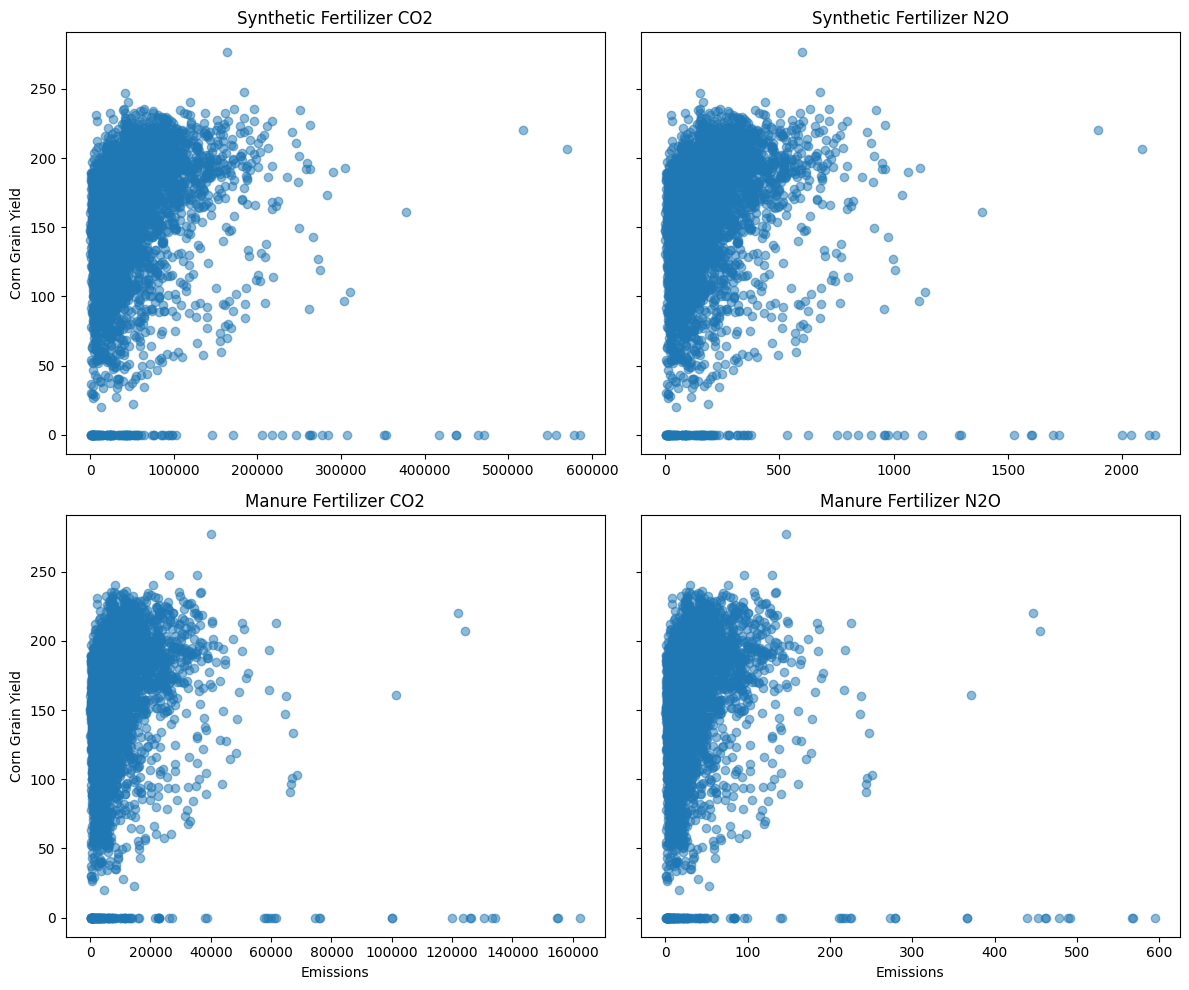

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)

# Synthetic CO2
ax[0,0].scatter(df['Synthetic Fertilizer CO2'], df['Corn Grain Yield'], alpha=0.5)
ax[0,0].set_title('Synthetic Fertilizer CO2')
ax[0,0].set_ylabel('Corn Grain Yield')

# Synthetic N2O
ax[0,1].scatter(df['Synthetic Fertilizer N2O'], df['Corn Grain Yield'], alpha=0.5)
ax[0,1].set_title('Synthetic Fertilizer N2O')

# Manure CO2
ax[1,0].scatter(df['Manure Fertilizer CO2'], df['Corn Grain Yield'], alpha=0.5)
ax[1,0].set_title('Manure Fertilizer CO2')
ax[1,0].set_xlabel('Emissions')
ax[1,0].set_ylabel('Corn Grain Yield')

# Manure N2O
ax[1,1].scatter(df['Manure Fertilizer N2O'], df['Corn Grain Yield'], alpha=0.5)
ax[1,1].set_title('Manure Fertilizer N2O')
ax[1,1].set_xlabel('Emissions')

plt.tight_layout()
plt.show();

## Distribution of Features

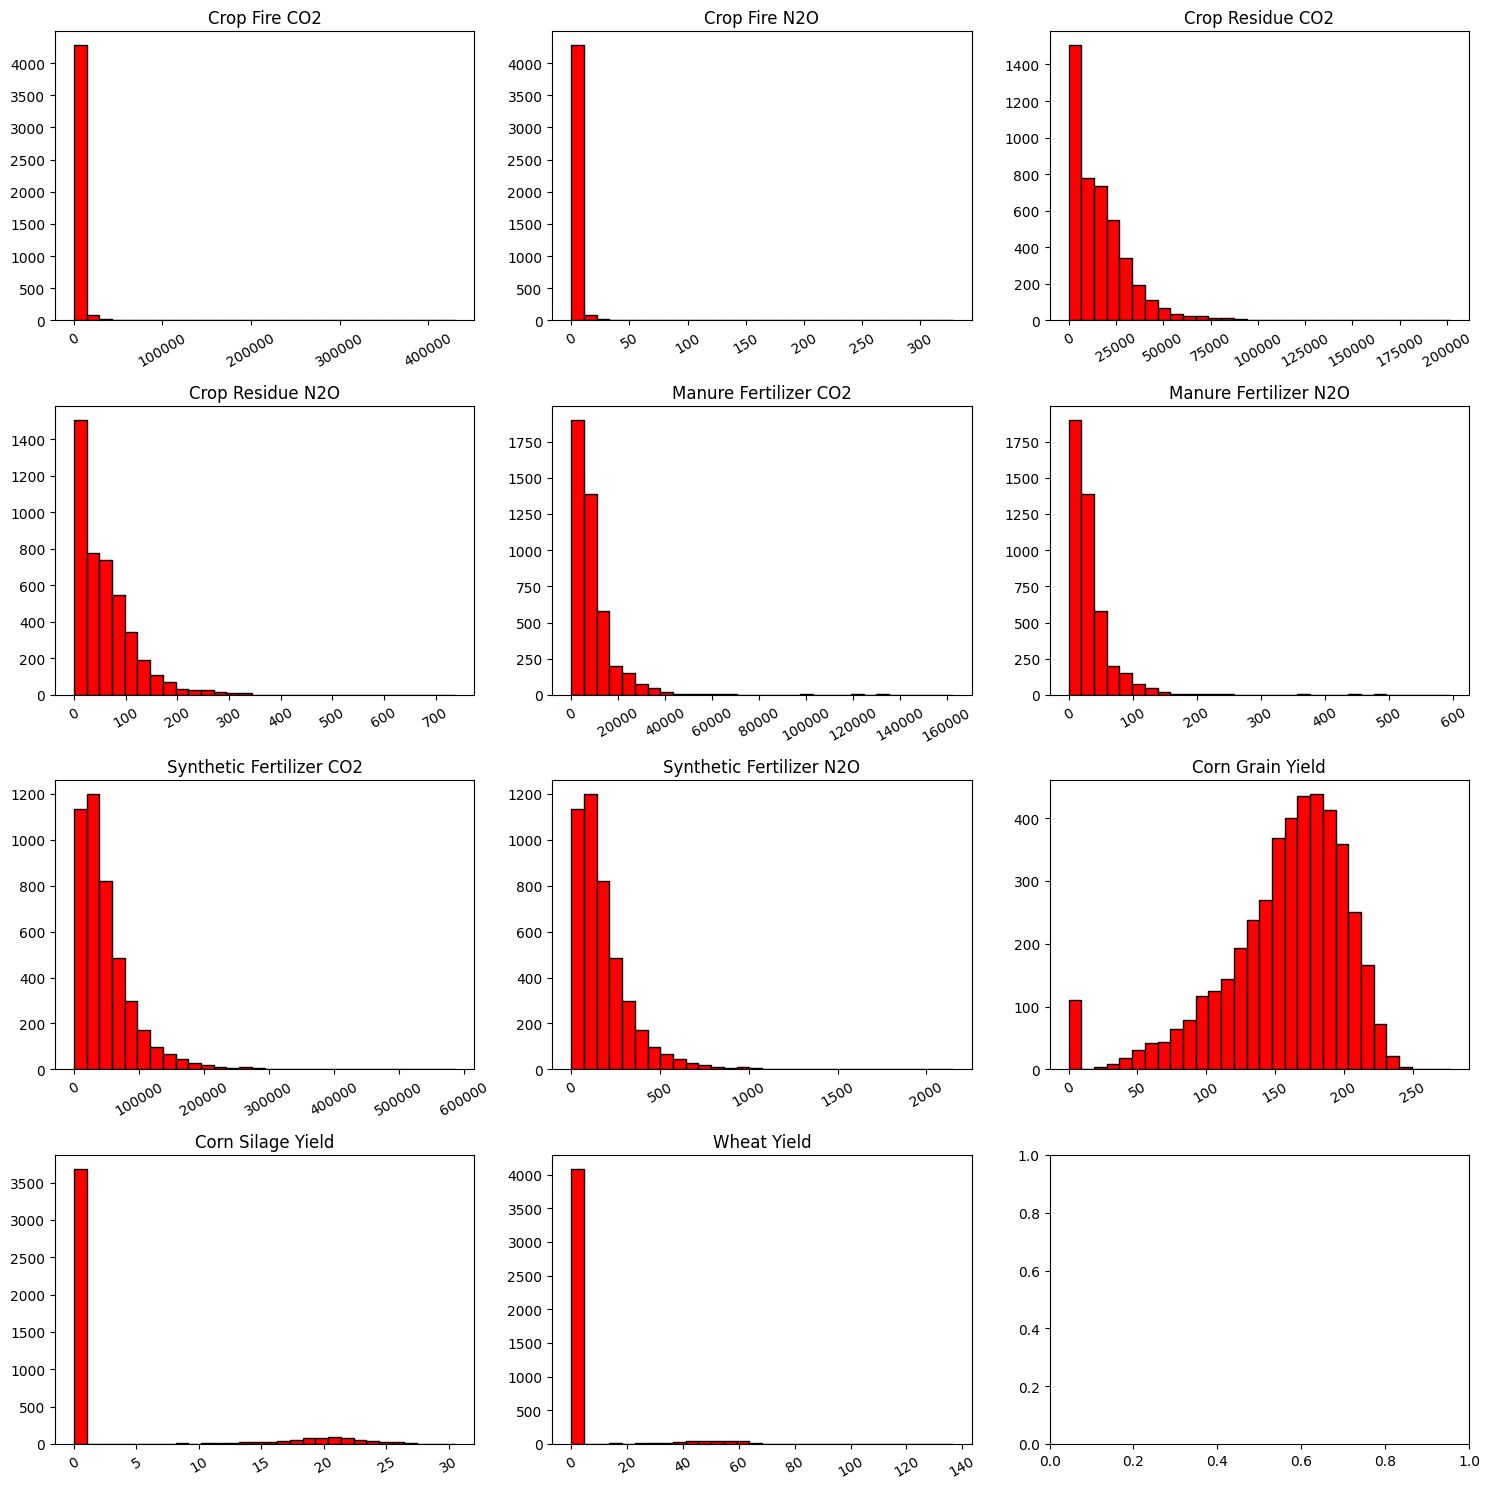

In [23]:
emission_cols = ['Crop Fire CO2', 'Crop Fire N2O', 'Crop Residue CO2', 'Crop Residue N2O',
                 'Manure Fertilizer CO2', 'Manure Fertilizer N2O',
                 'Synthetic Fertilizer CO2', 'Synthetic Fertilizer N2O']

yield_cols = ['Corn Grain Yield', 'Corn Silage Yield', 'Wheat Yield']

fig, axes = plt.subplots(4, 3, figsize=(15,15))
axes = axes.flatten()

for i, col in enumerate(emission_cols + yield_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='red', edgecolor='k')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show();

## Correlation of Features

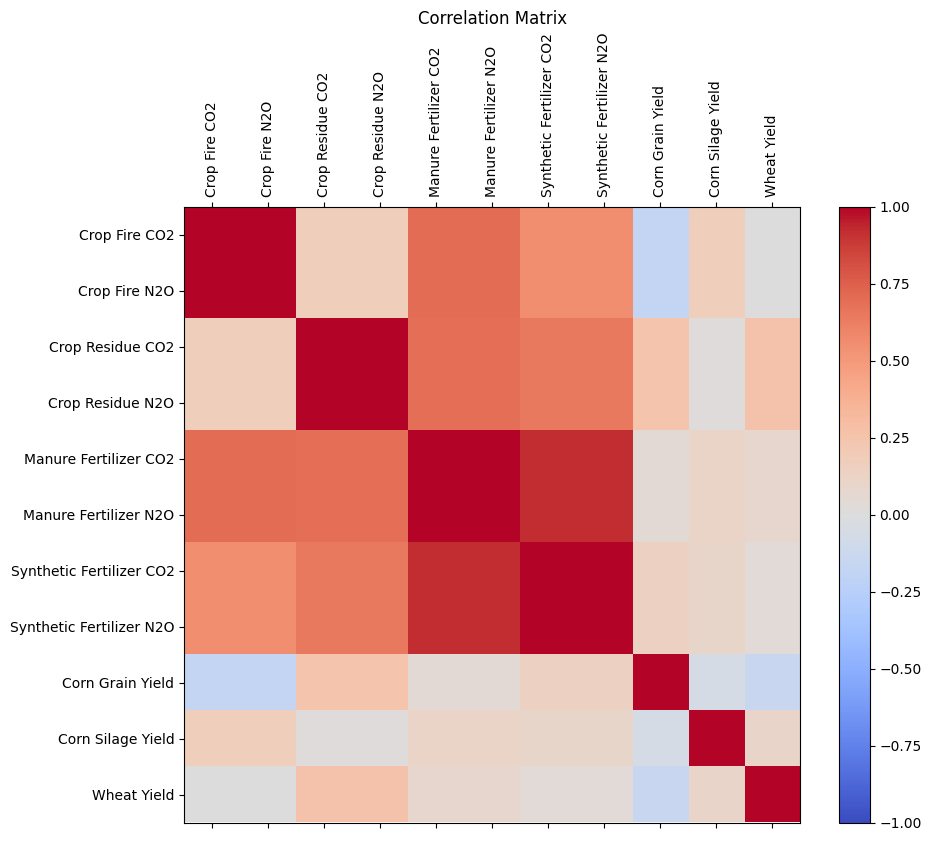

In [28]:
numeric_cols = emission_cols + yield_cols
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)
plt.title("Correlation Matrix")
plt.show();

## Time Series Corn Yield

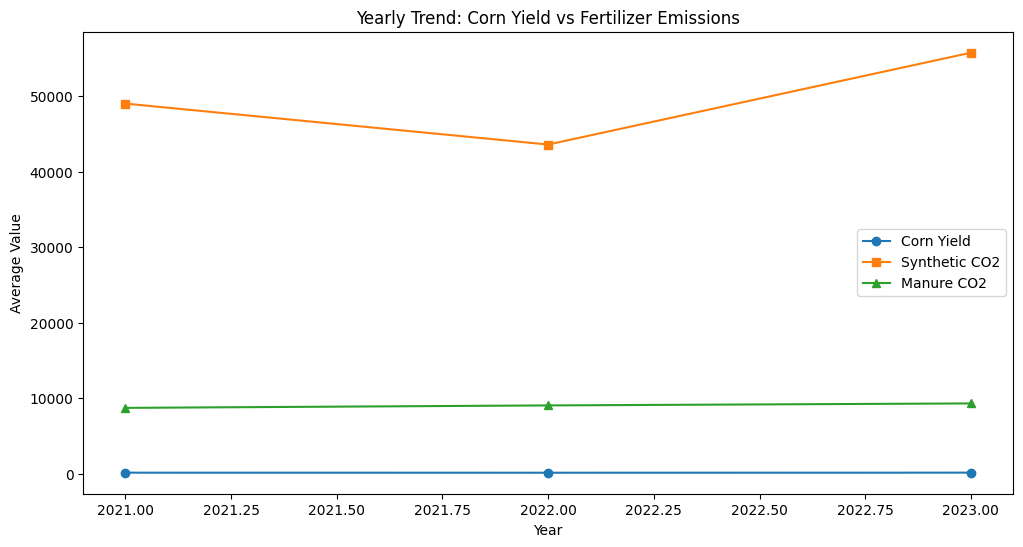

In [27]:
yearly = df.groupby('Year')[['Corn Grain Yield', 
                             'Synthetic Fertilizer CO2', 
                             'Manure Fertilizer CO2']].mean()

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(yearly.index, yearly['Corn Grain Yield'], marker='o', label='Corn Yield')
ax.plot(yearly.index, yearly['Synthetic Fertilizer CO2'], marker='s', label='Synthetic CO2')
ax.plot(yearly.index, yearly['Manure Fertilizer CO2'], marker='^', label='Manure CO2')

ax.set_xlabel('Year')
ax.set_ylabel('Average Value')
ax.set_title('Yearly Trend: Corn Yield vs Fertilizer Emissions')
ax.legend()
plt.show();